In [17]:
from sklearn.datasets import fetch_california_housing

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats.stats import pearsonr

/tmp/ipykernel_382763/339228804.py:5: DeprecationWarning: Please import `pearsonr` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.stats.stats import pearsonr


In [5]:
%matplotlib inline

In [7]:
dataset = pd.read_csv('BostonHousing.csv')
dataset

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [9]:
#machine learning models do not depend on normally distributed data

In [15]:
mean_expected = dataset['medv'].mean()

In [14]:
np.mean(dataset['medv'])

np.float64(22.532806324110677)

In [22]:
squared_errors = pd.Series(mean_expected - dataset['medv'])**2

In [26]:
sse = np.sum(squared_errors)
sse

np.float64(42716.29541501977)

<Axes: ylabel='Frequency'>

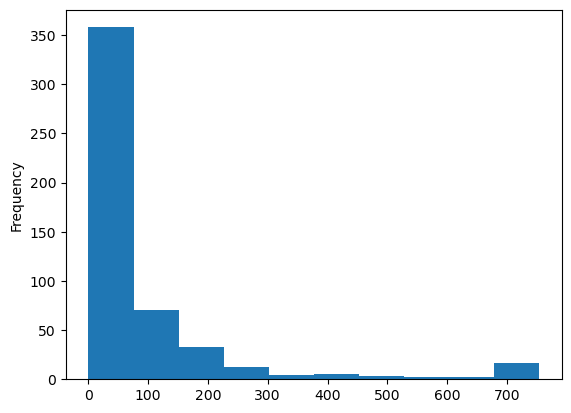

In [30]:
squared_errors.plot(kind='hist')

#the larger a house is the more expensive is
the variables have to be standardarized

Z score standardization

mean 0
and standard deviation of 1

correlation is covariance standardizada

In [93]:
def standardize(x):
    return (x-np.mean(x)) / np.std(x)

#es un producto punto 
def covariance(x,y,bias=0):
    obs = float(len(x))
    return (
        np.sum(
            (x-np.mean(x)) * (y-np.mean(y))
        ) / 
        (obs - min(bias,1))
    )
    
def pearsonr_correlation(x,y,bias=0):
    return covariance(
        standardize(x),
        standardize(y), 
        bias=bias
              )
    
#is positive y la fuerza es buena hay correlacion!

In [69]:
0.69536

0.69536

In [100]:
print (
    '%0.5f' %
    (
        pearsonr(dataset['age'],dataset['medv'])[0]
    )
)
print (
    '%0.5f' % 
    (
        pearsonr_correlation(dataset['age'],dataset['medv'])
    )
)

-0.37695
-0.37695
